---

<div align="center">
  <img src="https://raw.githubusercontent.com/devicons/devicon/master/icons/python/python-original.svg" width="80"/>
</div>

<h1 align="center">Redes Neurais Artificiais, Deep Learning e Algoritmos Genéticos</h1>

<h3 align="center">PhD. Julles Mitoura</h3>

<div align="center">
  <img src="https://img.shields.io/badge/Python-3776AB?style=for-the-badge&logo=python&logoColor=white"/>
  <img src="https://img.shields.io/badge/Jupyter-F37626?style=for-the-badge&logo=jupyter&logoColor=white"/>
  <img src="https://img.shields.io/badge/PyTorch-EE4C2C?style=for-the-badge&logo=pytorch&logoColor=white"/>
</div>

---

## Instalação das dependências

| Biblioteca | Uso |
|------------|-----|
| `numpy` | Geração e manipulação dos datasets |
| `matplotlib` | Visualizações |
| `scikit-learn` | Normalização (`StandardScaler`) e métricas |
| `torch` | Tensores, LSTM e otimizadores |

In [1]:
# %pip install numpy matplotlib scikit-learn torch --quiet

## Aula 05: Long Short-Term Memory (LSTM)

A FNN da Aula 03 trata cada exemplo de forma **independente**  não há memória entre uma entrada e a próxima. Para dados sequenciais (séries temporais, texto, sinais), a ordem importa: o que veio antes influencia o que vem depois.

As **Redes Recorrentes (RNNs)** foram criadas para isso. A LSTM é a variante mais utilizada, projetada para aprender dependências de longo prazo sem sofrer do problema do gradiente que desvanece.

### Roteiro

| Seção | Conteúdo |
|-------|----------|
| **1** | Por que RNNs? O problema das sequências |
| **2** | Arquitetura LSTM  gates e estado de célula |
| **3** | Bibliotecas e configuração |
| **4** | Caso 1: Previsão de série temporal (regressão) |
| **5** | Caso 2: Classificação de sequências |
| **6** | Comparativo e próximos passos |

---

## 1. Por que RNNs?

Uma FNN recebe um vetor fixo e produz uma saída  sem noção de tempo ou ordem. Para processar sequências, precisamos de um modelo que **mantenha estado** entre os passos:

$$h_t = f(x_t,\, h_{t-1})$$

onde $h_t$ é o **estado oculto** no passo $t$, $x_t$ é a entrada atual e $h_{t-1}$ é a memória do passo anterior.

### O problema do gradiente que desvanece

Em RNNs simples, o gradiente é multiplicado pelo mesmo peso a cada passo no tempo. Para sequências longas:

- Se o peso < 1: o gradiente **diminui exponencialmente** → a rede esquece o passado distante
- Se o peso > 1: o gradiente **explode** → treino instável

A **LSTM** resolve isso com um mecanismo de **gates** que controla seletivamente o que lembrar e o que esquecer.

---

## 2. Arquitetura LSTM

A LSTM mantém dois vetores de estado:

- $h_t$  **estado oculto** (*hidden state*): memória de curto prazo, passada para a próxima camada
- $c_t$  **estado de célula** (*cell state*): memória de longo prazo, protegida pelos gates

### Os três gates

| Gate | Símbolo | Função |
|------|---------|--------|
| **Forget gate** | $f_t$ | Decide o que descartar de $c_{t-1}$: $f_t = \sigma(W_f [h_{t-1}, x_t] + b_f)$ |
| **Input gate** | $i_t$ | Decide o que adicionar a $c_t$: $i_t = \sigma(W_i [h_{t-1}, x_t] + b_i)$ |
| **Output gate** | $o_t$ | Decide o que expor como $h_t$: $o_t = \sigma(W_o [h_{t-1}, x_t] + b_o)$ |

O estado de célula é atualizado como:

$$c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t$$

$$h_t = o_t \odot \tanh(c_t)$$

onde $\tilde{c}_t = \tanh(W_c [h_{t-1}, x_t] + b_c)$ é o candidato a nova memória e $\odot$ é a multiplicação elemento a elemento.

### FNN vs LSTM

| Aspecto | FNN (Aula 03) | LSTM (Aula 05) |
|---------|--------------|----------------|
| **Entrada** | Vetor fixo | Sequência de vetores |
| **Memória** | Nenhuma | Estado oculto $h_t$ + célula $c_t$ |
| **Uso típico** | Tabular, imagem (flat) | Séries temporais, texto, sinais |
| **PyTorch** | `nn.Linear` | `nn.LSTM` |

---

## 3. Bibliotecas

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}  |  PyTorch {torch.__version__}")

Dispositivo: cpu  |  PyTorch 2.11.0


## 4. Caso 1  Previsão de Temperatura (Regressão)

**Dataset:** [Jena Climate 2009–2016](https://www.kaggle.com/datasets/mnassrib/jena-climate)  estação meteorológica do Instituto Max Planck, Jena, Alemanha. Leituras a cada 10 minutos, reamostradas para **1 hora**.

**Objetivo:** prever a **temperatura do ar** `T (degC)` a partir de uma janela de `SEQ_LEN` horas de 8 variáveis meteorológicas.

| Feature | Descrição |
|---|---|
| `p (mbar)` | Pressão atmosférica |
| `Tdew (degC)` | Ponto de orvalho |
| `rh (%)` | Umidade relativa |
| `VPmax (mbar)` | Pressão máxima de vapor |
| `VPact (mbar)` | Pressão real de vapor |
| `sh (g/kg)` | Umidade específica |
| `wv (m/s)` | Velocidade do vento |
| `wd (deg)` | Direção do vento |

### 4.1 Arquitetura many-to-one

```
(SEQ_LEN horas, 8 features) → [LSTM] → h_T → [Linear] → T (degC)
```

Shape : 70,089 linhas × 15 colunas
Período: 01.01.2009 00:10:00  →  31.12.2016 23:20:00
       p (mbar)  Tdew (degC)    rh (%)  VPmax (mbar)  VPact (mbar)  sh (g/kg)  \
count  70089.00     70089.00  70089.00      70089.00      70089.00   70089.00   
mean     989.21         4.95     76.01         13.58          9.53       6.02   
std        8.36         6.73     16.48          7.74          4.18       2.66   
min      914.10       -25.01     14.20          0.95          0.79       0.50   
25%      984.20         0.23     65.21          7.78          6.21       3.92   
50%      989.58         5.22     79.30         11.82          8.86       5.59   
75%      994.72        10.06     89.40         17.60         12.35       7.80   
max     1015.28        23.11    100.00         63.26         28.32      18.13   

       wv (m/s)  wd (deg)  T (degC)  
count  70089.00  70089.00  70089.00  
mean       2.13    175.02      9.45  
std        1.54     86.80      8.42  
min        0.00      0.00    -

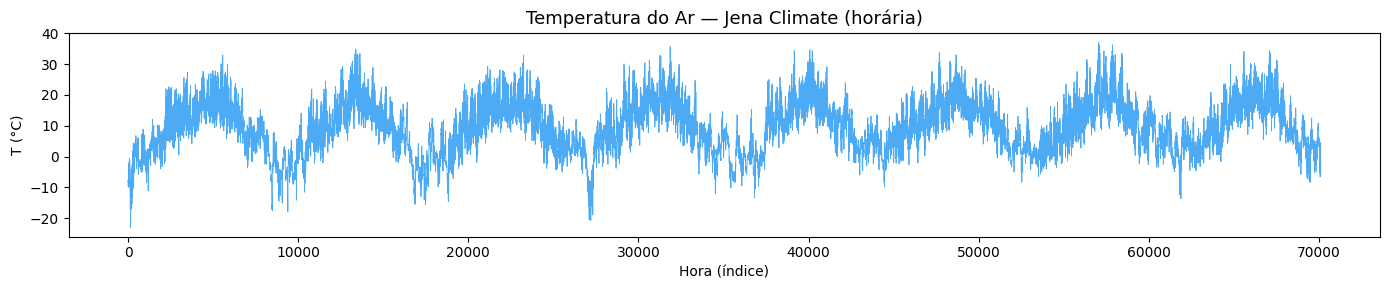

In [3]:
FEATURES = ["p (mbar)", "Tdew (degC)", "rh (%)", "VPmax (mbar)",
            "VPact (mbar)", "sh (g/kg)", "wv (m/s)", "wd (deg)"]
TARGET   = "T (degC)"

# ── Carrega e reamostra para frequência horária (a cada 6 linhas) ─────────
df = pd.read_csv("data/jena/jena_climate_2009_2016.csv")
df = df.iloc[::6].reset_index(drop=True)          # 10 min → 1 hora

# Remove leituras inválidas de velocidade do vento (-9999)
df["wv (m/s)"]     = df["wv (m/s)"].replace(-9999.0, np.nan)
df["max. wv (m/s)"]= df["max. wv (m/s)"].replace(-9999.0, np.nan)
df = df.dropna(subset=FEATURES + [TARGET]).reset_index(drop=True)

print(f"Shape : {df.shape[0]:,} linhas × {df.shape[1]} colunas")
print(f"Período: {df['Date Time'].iloc[0]}  →  {df['Date Time'].iloc[-1]}")
print(df[FEATURES + [TARGET]].describe().round(2))

# ── Visualização: temperatura ao longo dos anos ───────────────────────────
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(df[TARGET].values, color="#2196F3", lw=0.6, alpha=0.8)
ax.set_title("Temperatura do Ar  Jena Climate (horária)", fontsize=13)
ax.set_ylabel("T (°C)"); ax.set_xlabel("Hora (índice)")
plt.tight_layout(); plt.show()

### 4.3 Preparação: Janela Deslizante

A LSTM recebe **sequências**. Transformamos a série em pares $(X, y)$ usando uma janela deslizante de tamanho $T$:

$$X_i = [s_{i},\, s_{i+1},\, \ldots,\, s_{i+T-1}], \quad y_i = s_{i+T}$$

Cada $X_i$ é uma sequência de $T$ passos e $y_i$ é o próximo valor a prever.

Usamos o `StandardScaler` do scikit-learn para normalizar  mais direto que funções manuais.

In [4]:
SEQ_LEN = 24   # 24 horas de histórico → prediz a próxima hora

# ── Normalização ──────────────────────────────────────────────────────────
scaler_X = StandardScaler().fit(df[FEATURES].values)
scaler_y = StandardScaler().fit(df[[TARGET]].values)

feat_norm = scaler_X.transform(df[FEATURES].values)
targ_norm = scaler_y.transform(df[[TARGET]].values).ravel()

# ── Janela deslizante ─────────────────────────────────────────────────────
X_all = np.array([feat_norm[i : i + SEQ_LEN] for i in range(len(feat_norm) - SEQ_LEN)])
y_all = targ_norm[SEQ_LEN:]

# ── Split cronológico 70 / 15 / 15 ───────────────────────────────────────
n    = len(X_all)
i_va = int(n * 0.70)
i_te = int(n * 0.85)

X_tr, y_tr = X_all[:i_va],     y_all[:i_va]
X_va, y_va = X_all[i_va:i_te], y_all[i_va:i_te]
X_te, y_te = X_all[i_te:],     y_all[i_te:]

# ── Tensores ──────────────────────────────────────────────────────────────
def to_t(arr, is_y=False):
    t = torch.tensor(arr, dtype=torch.float32).to(device)
    return t.unsqueeze(1) if is_y else t

X_tr_t, y_tr_t = to_t(X_tr), to_t(y_tr, True)
X_va_t, y_va_t = to_t(X_va), to_t(y_va, True)
X_te_t, y_te_t = to_t(X_te), to_t(y_te, True)

loader_tr = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=128, shuffle=False)

print(f"Treino   : {X_tr.shape[0]:>6,} amostras")
print(f"Validação: {X_va.shape[0]:>6,} amostras")
print(f"Teste    : {X_te.shape[0]:>6,} amostras")
print(f"Shape    : {X_tr.shape}  →  (amostras, seq_len={SEQ_LEN}, features={len(FEATURES)})")

Treino   : 49,045 amostras
Validação: 10,510 amostras
Teste    : 10,510 amostras
Shape    : (49045, 24, 8)  →  (amostras, seq_len=24, features=8)


### 4.4 Modelo LSTM

O `nn.LSTM` do PyTorch processa a sequência inteira e retorna:
- `output`: saída $h_t$ em **cada** passo de tempo  shape `(batch, seq_len, hidden_size)`
- `(h_n, c_n)`: estado oculto e de célula do **último** passo

Para previsão, usamos apenas a saída do **último passo** (`output[:, -1, :]`), que carrega toda a informação acumulada da sequência.

In [5]:
class PrevisaoLSTM(nn.Module):
    """
    LSTM many-to-one  Previsão de temperatura.

    Entrada : (batch, seq_len, 8)  → 8 variáveis meteorológicas por hora
    Saída   : (batch, 1)           → T (degC) na próxima hora
    """
    def __init__(self, input_size=8, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size,
                            num_layers=num_layers,
                            batch_first=True,
                            dropout=dropout)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(self.drop(out[:, -1, :]))


modelo_reg = PrevisaoLSTM(input_size=len(FEATURES)).to(device)
print(modelo_reg)
n_params = sum(p.numel() for p in modelo_reg.parameters() if p.requires_grad)
print(f"\nParâmetros treináveis: {n_params:,}")

PrevisaoLSTM(
  (lstm): LSTM(8, 64, num_layers=2, batch_first=True, dropout=0.2)
  (drop): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Parâmetros treináveis: 52,289


### 4.5 Treinamento

Época   1 | Treino: 0.20433 | Val: 0.03182
Época   5 | Treino: 0.02076 | Val: 0.01224
Época  10 | Treino: 0.01820 | Val: 0.00983
Época  15 | Treino: 0.01740 | Val: 0.01140
Early stopping na época 20


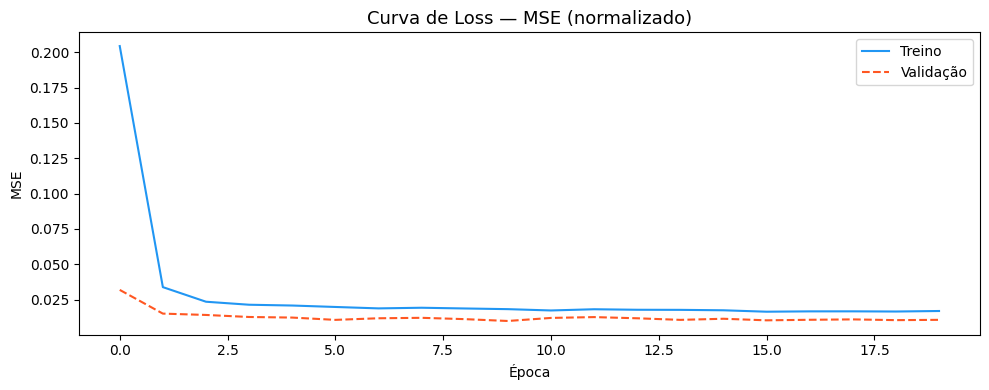

In [6]:
EPOCHS   = 50
LR       = 1e-3
PATIENCE = 10

criterio   = nn.MSELoss()
otimizador = optim.Adam(modelo_reg.parameters(), lr=LR)

hist_tr, hist_va   = [], []
melhor_loss_va     = float("inf")
melhor_pesos       = None
epocas_sem_melhora = 0

for epoca in range(1, EPOCHS + 1):
    modelo_reg.train()
    loss_tr = 0.0
    for xb, yb in loader_tr:
        otimizador.zero_grad()
        loss = criterio(modelo_reg(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(modelo_reg.parameters(), max_norm=1.0)
        otimizador.step()
        loss_tr += loss.item()
    loss_tr /= len(loader_tr)

    modelo_reg.eval()
    with torch.no_grad():
        loss_va = criterio(modelo_reg(X_va_t), y_va_t).item()

    hist_tr.append(loss_tr)
    hist_va.append(loss_va)

    if loss_va < melhor_loss_va:
        melhor_loss_va = loss_va
        melhor_pesos   = {k: v.clone() for k, v in modelo_reg.state_dict().items()}
        epocas_sem_melhora = 0
    else:
        epocas_sem_melhora += 1
        if epocas_sem_melhora >= PATIENCE:
            print(f"Early stopping na época {epoca}")
            break

    if epoca % 5 == 0 or epoca == 1:
        print(f"Época {epoca:>3} | Treino: {loss_tr:.5f} | Val: {loss_va:.5f}")

modelo_reg.load_state_dict(melhor_pesos)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hist_tr, label="Treino",    color="#2196F3", lw=1.5)
ax.plot(hist_va, label="Validação", color="#FF5722", lw=1.5, linestyle="--")
ax.set_title("Curva de Loss  MSE (normalizado)", fontsize=13)
ax.set_xlabel("Época"); ax.set_ylabel("MSE"); ax.legend()
plt.tight_layout(); plt.show()

### 4.6 Resultados

Conjunto        RMSE (°C)   MAE (°C)         R²
----------------------------------------------------
Validação          0.8352     0.6111     0.9884
Teste              0.8084     0.6021     0.9892


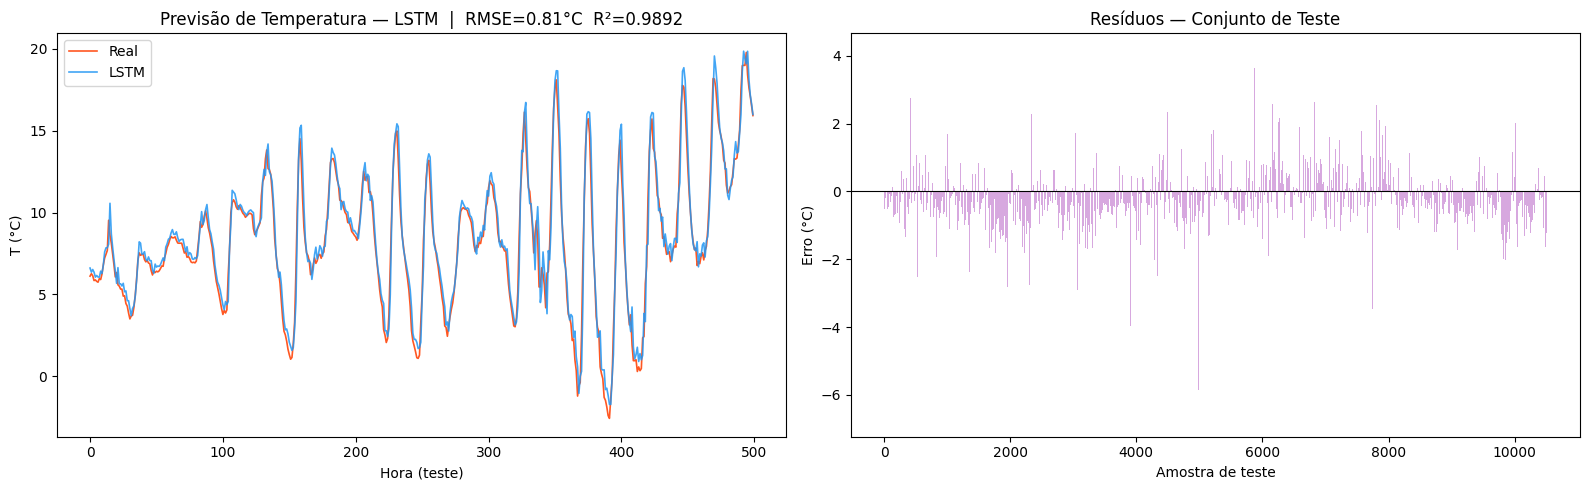

In [7]:
modelo_reg.eval()
with torch.no_grad():
    pred_norm_va = modelo_reg(X_va_t).cpu().numpy().flatten()
    pred_norm_te = modelo_reg(X_te_t).cpu().numpy().flatten()

def desnorm(arr):
    return scaler_y.inverse_transform(arr.reshape(-1, 1)).flatten()

pred_va, real_va = desnorm(pred_norm_va), desnorm(y_va)
pred_te, real_te = desnorm(pred_norm_te), desnorm(y_te)

def metricas(real, pred):
    rmse = np.sqrt(np.mean((real - pred) ** 2))
    mae  = np.mean(np.abs(real - pred))
    r2   = 1 - np.sum((real - pred) ** 2) / np.sum((real - real.mean()) ** 2)
    return rmse, mae, r2

rmse_va, mae_va, r2_va = metricas(real_va, pred_va)
rmse_te, mae_te, r2_te = metricas(real_te, pred_te)

print("=" * 52)
print(f"{'Conjunto':<14} {'RMSE (°C)':>10} {'MAE (°C)':>10} {'R²':>10}")
print("-" * 52)
print(f"{'Validação':<14} {rmse_va:>10.4f} {mae_va:>10.4f} {r2_va:>10.4f}")
print(f"{'Teste':<14} {rmse_te:>10.4f} {mae_te:>10.4f} {r2_te:>10.4f}")
print("=" * 52)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
n_plot = min(500, len(real_te))
ax.plot(real_te[:n_plot], label="Real",     color="#FF5722", lw=1.2)
ax.plot(pred_te[:n_plot], label="LSTM",     color="#2196F3", lw=1.2, alpha=0.85)
ax.set_title(f"Previsão de Temperatura  LSTM  |  RMSE={rmse_te:.2f}°C  R²={r2_te:.4f}", fontsize=12)
ax.set_ylabel("T (°C)"); ax.set_xlabel("Hora (teste)"); ax.legend()

ax = axes[1]
residuos = real_te - pred_te
ax.bar(range(len(residuos)), residuos, color="#9C27B0", alpha=0.4, width=1)
ax.axhline(0, color="black", lw=0.8)
ax.set_title("Resíduos  Conjunto de Teste", fontsize=12)
ax.set_ylabel("Erro (°C)"); ax.set_xlabel("Amostra de teste")

plt.tight_layout(); plt.show()

In [8]:
# ── 4.7 Salvar o modelo treinado ─────────────────────────────────────────────
# torch.save persiste o state_dict (pesos) e os objetos auxiliares (scaler,
# metadados da arquitetura) num único checkpoint .pth.
# Para recarregar, basta chamar torch.load() e reconstituir a classe do modelo.

import os, pickle
os.makedirs("models", exist_ok=True)

checkpoint_reg = {
    "model_state_dict": modelo_reg.state_dict(),
    "scaler_X":         scaler_X,           # normaliza as 8 features de entrada
    "scaler_y":         scaler_y,           # normaliza o alvo T (degC)
    "seq_len":          SEQ_LEN,            # 24 horas de histórico
    "features":         FEATURES,           # lista com os nomes das 8 colunas
    "input_size":       len(FEATURES),      # 8
    "hidden_size":      64,
    "num_layers":       2,
}

torch.save(checkpoint_reg, "models/lstm_temperatura.pth")
print("✓ Modelo de temperatura salvo em  models/lstm_temperatura.pth")

✓ Modelo de temperatura salvo em  models/lstm_temperatura.pth


---

## 5. Caso 2  Reconhecimento de Atividade Humana (Classificação)

### 5.1 Objetivo

Dado um trecho de 2,56 segundos de sinais de acelerômetro e giroscópio capturados por um smartphone, classificar a **atividade** que o usuário está realizando  o modelo precisa reconhecer o **padrão temporal** completo da janela, não apenas valores pontuais.

### 5.2 Dataset: UCI HAR (Human Activity Recognition)

**Fonte:** [UCI Machine Learning Repository  Human Activity Recognition](https://archive.ics.uci.edu/dataset/240/human+activity+recognition+using+smartphones)

| Atributo | Valor |
|----------|-------|
| Amostras (treino) | 7 352 |
| Amostras (teste) | 2 947 |
| Timesteps por amostra | 128 (a 50 Hz → 2,56 s) |
| Canais (features) | 9 sinais inerciais |
| Classes | 6 atividades |

**Canais:**

| Canal | Descrição |
|-------|-----------|
| `body_acc_x/y/z` | Aceleração do corpo (eixos X, Y, Z) |
| `body_gyro_x/y/z` | Velocidade angular (giroscópio X, Y, Z) |
| `total_acc_x/y/z` | Aceleração total (inclui gravidade X, Y, Z) |

**Atividades:**

| Label | Classe |
|-------|--------|
| 0 | WALKING |
| 1 | WALKING UPSTAIRS |
| 2 | WALKING DOWNSTAIRS |
| 3 | SITTING |
| 4 | STANDING |
| 5 | LAYING |

> **Por que HAR?** As 6 classes têm assinaturas temporais muito distintas  caminhar é periódico e rítmico, sentar é quase estático. Uma LSTM captura esse comportamento ao longo da janela de forma natural.


In [9]:
HAR_ROOT = "data/har/UCI HAR Dataset"

CANAIS = [
    "body_acc_x",  "body_acc_y",  "body_acc_z",
    "body_gyro_x", "body_gyro_y", "body_gyro_z",
    "total_acc_x", "total_acc_y", "total_acc_z",
]

NOMES_CLF = ["WALKING", "WALKING\nUPSTAIRS", "WALKING\nDOWNSTAIRS",
             "SITTING", "STANDING", "LAYING"]

def carregar_har(split):
    """Carrega os 9 canais inerciais e os rótulos para train ou test."""
    sinais = []
    for canal in CANAIS:
        arq = f"{HAR_ROOT}/{split}/Inertial Signals/{canal}_{split}.txt"
        sinais.append(np.loadtxt(arq))          # (N, 128)
    X = np.stack(sinais, axis=-1)               # (N, 128, 9)
    y = np.loadtxt(f"{HAR_ROOT}/{split}/y_{split}.txt", dtype=int) - 1  # 0-indexed
    return X, y

X_tr_raw, y_tr_c = carregar_har("train")
X_te_raw, y_te_c = carregar_har("test")

print(f"Treino  : {X_tr_raw.shape}  |  rótulos: {y_tr_c.shape}")
print(f"Teste   : {X_te_raw.shape}  |  rótulos: {y_te_c.shape}")
print(f"Classes : {np.unique(y_tr_c)}  (0 = WALKING … 5 = LAYING)")


Treino  : (7352, 128, 9)  |  rótulos: (7352,)
Teste   : (2947, 128, 9)  |  rótulos: (2947,)
Classes : [0 1 2 3 4 5]  (0 = WALKING … 5 = LAYING)


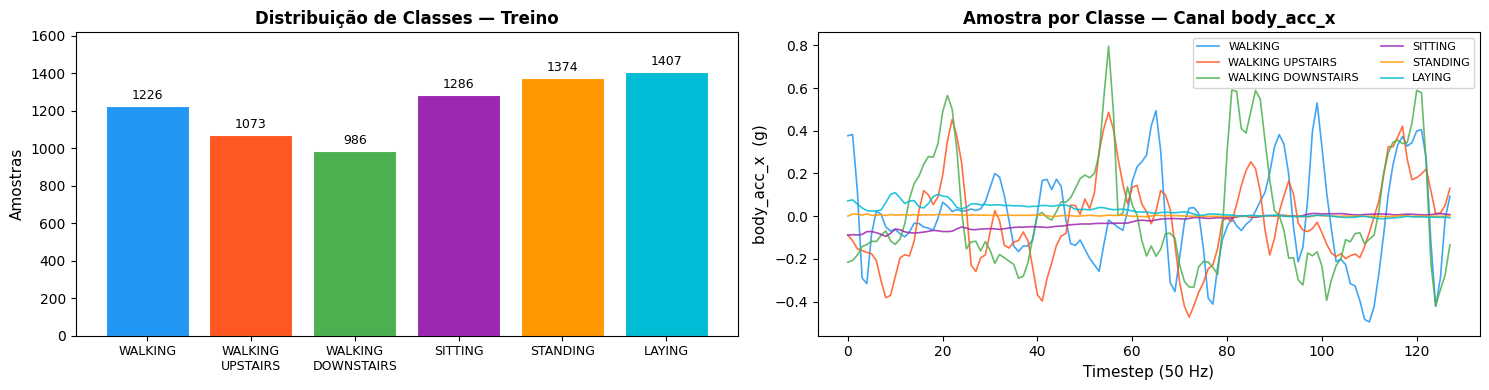

In [10]:
# Distribuição de classes
contagem = np.bincount(y_tr_c)
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

ax = axes[0]
cores_bar = ["#2196F3", "#FF5722", "#4CAF50", "#9C27B0", "#FF9800", "#00BCD4"]
bars = ax.bar(range(6), contagem, color=cores_bar, edgecolor="white", linewidth=0.8)
ax.set_xticks(range(6))
ax.set_xticklabels(NOMES_CLF, fontsize=9)
ax.set_ylabel("Amostras", fontsize=11)
ax.set_title("Distribuição de Classes  Treino", fontsize=12, fontweight="bold")
for bar, n in zip(bars, contagem):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            str(n), ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, contagem.max() * 1.15)

# Um exemplo por classe (canal body_acc_x, índice 0)
ax = axes[1]
for cls in range(6):
    idx = np.where(y_tr_c == cls)[0][0]
    ax.plot(X_tr_raw[idx, :, 0], label=NOMES_CLF[cls].replace("\n", " "),
            color=cores_bar[cls], lw=1.2, alpha=0.85)
ax.set_xlabel("Timestep (50 Hz)", fontsize=11)
ax.set_ylabel("body_acc_x  (g)", fontsize=11)
ax.set_title("Amostra por Classe  Canal body_acc_x", fontsize=12, fontweight="bold")
ax.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()


### 5.3 Preparação dos Dados

O HAR já vem dividido em treino e teste pelos autores (divisão por voluntário  sem vazamento). Apenas normalizamos cada canal independentemente usando o conjunto de treino.

| Conjunto | Amostras | Fonte |
|----------|----------|-------|
| Treino   | 7 352    | `train/` |
| Teste    | 2 947    | `test/`  |

> **Normalização por canal:** cada um dos 9 canais é padronizado com média e desvio calculados no treino e aplicados ao teste  evita que canais de maior amplitude dominem o gradiente.


In [11]:
# Normalização por canal (fit apenas no treino)
# X shape: (N, 128, 9) → reshape para (N*128, 9), normaliza, reshape de volta
N_tr, T, C = X_tr_raw.shape
scaler_clf = StandardScaler()
X_tr_norm = scaler_clf.fit_transform(X_tr_raw.reshape(-1, C)).reshape(N_tr, T, C)
X_te_norm = scaler_clf.transform(X_te_raw.reshape(-1, C)).reshape(-1, T, C)

# Tensores
X_tr_ct = torch.tensor(X_tr_norm, dtype=torch.float32).to(device)
y_tr_ct = torch.tensor(y_tr_c,    dtype=torch.long).to(device)
X_te_ct = torch.tensor(X_te_norm, dtype=torch.float32).to(device)
y_te_ct = torch.tensor(y_te_c,    dtype=torch.long).to(device)

loader_tr_c = DataLoader(TensorDataset(X_tr_ct, y_tr_ct),
                         batch_size=128, shuffle=True)

print(f"X treino : {X_tr_ct.shape}  |  y treino : {y_tr_ct.shape}")
print(f"X teste  : {X_te_ct.shape}  |  y teste  : {y_te_ct.shape}")


X treino : torch.Size([7352, 128, 9])  |  y treino : torch.Size([7352])
X teste  : torch.Size([2947, 128, 9])  |  y teste  : torch.Size([2947])


### 5.4 Modelo LSTM para Classificação

A estrutura é idêntica à de regressão  LSTM many-to-one  mas a saída é um vetor de **6 logits** (um por classe), e a perda é `CrossEntropyLoss`.

```
Entrada  : (batch, 128, 9)   ← 128 timesteps, 9 canais
LSTM     : hidden=128, layers=2, dropout=0.3
Saída h_T: (batch, 128)      ← último estado oculto
FC       : Linear(128 → 6)
Loss     : CrossEntropyLoss
```

> O dropout é aplicado entre as camadas LSTM e antes da camada linear para regularização  o HAR tem 7 352 amostras de treino, o suficiente para overfitting leve.


In [12]:
class ClassificacaoLSTM(nn.Module):
    """LSTM many-to-one para classificação de atividade humana."""

    def __init__(self, input_size=9, hidden_size=128, num_layers=2,
                 n_classes=6, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size, hidden_size, num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden_size, n_classes)

    def forward(self, x):
        # x: (batch, seq, features)
        out, _ = self.lstm(x)       # out: (batch, seq, hidden)
        h_last  = out[:, -1, :]    # último timestep
        return self.fc(self.drop(h_last))


modelo_clf = ClassificacaoLSTM(input_size=9, hidden_size=128,
                                num_layers=2, n_classes=6).to(device)

n_params = sum(p.numel() for p in modelo_clf.parameters() if p.requires_grad)
print(f"Parâmetros treináveis: {n_params:,}")
print(modelo_clf)


Parâmetros treináveis: 204,038
ClassificacaoLSTM(
  (lstm): LSTM(9, 128, num_layers=2, batch_first=True, dropout=0.3)
  (drop): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=6, bias=True)
)


### 5.5 Treinamento

| Hiperparâmetro | Valor |
|----------------|-------|
| Épocas         | 30    |
| Learning rate  | 1e-3  |
| Batch size     | 128   |
| Otimizador     | Adam  |
| Perda          | CrossEntropyLoss |
| Clip gradiente | 1.0   |


In [13]:
EPOCHS_CLF = 30
LR_CLF     = 1e-3

criterio_clf   = nn.CrossEntropyLoss()
otimizador_clf = optim.Adam(modelo_clf.parameters(), lr=LR_CLF)

hist_loss_tr_c, hist_loss_te_c = [], []
hist_acc_tr_c,  hist_acc_te_c  = [], []

for epoca in range(1, EPOCHS_CLF + 1):

    # ── Treino ──────────────────────────────────────────────────
    modelo_clf.train()
    loss_soma, acertos, total = 0.0, 0, 0
    for xb, yb in loader_tr_c:
        logits = modelo_clf(xb)
        loss   = criterio_clf(logits, yb)
        otimizador_clf.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(modelo_clf.parameters(), 1.0)
        otimizador_clf.step()
        loss_soma += loss.item() * len(yb)
        acertos   += (logits.argmax(1) == yb).sum().item()
        total     += len(yb)
    hist_loss_tr_c.append(loss_soma / total)
    hist_acc_tr_c.append(acertos  / total)

    # ── Avaliação (teste) ───────────────────────────────────────
    modelo_clf.eval()
    with torch.no_grad():
        logits_te = modelo_clf(X_te_ct)
        loss_te   = criterio_clf(logits_te, y_te_ct).item()
        acc_te    = (logits_te.argmax(1) == y_te_ct).float().mean().item()
    hist_loss_te_c.append(loss_te)
    hist_acc_te_c.append(acc_te)

    if epoca % 5 == 0 or epoca == 1:
        print(f"Época {epoca:3d}/{EPOCHS_CLF}  "
              f"loss treino={hist_loss_tr_c[-1]:.4f}  "
              f"loss teste={loss_te:.4f}  "
              f"acc teste={acc_te*100:.1f}%")


Época   1/30  loss treino=1.1899  loss teste=0.9271  acc teste=59.5%
Época   5/30  loss treino=0.1748  loss teste=0.4052  acc teste=87.5%
Época  10/30  loss treino=0.1297  loss teste=0.2727  acc teste=91.0%
Época  15/30  loss treino=0.1213  loss teste=0.2767  acc teste=92.1%
Época  20/30  loss treino=0.1054  loss teste=0.3444  acc teste=91.4%
Época  25/30  loss treino=0.1026  loss teste=0.3433  acc teste=91.0%
Época  30/30  loss treino=0.1099  loss teste=0.3171  acc teste=92.3%


### 5.6 Resultados


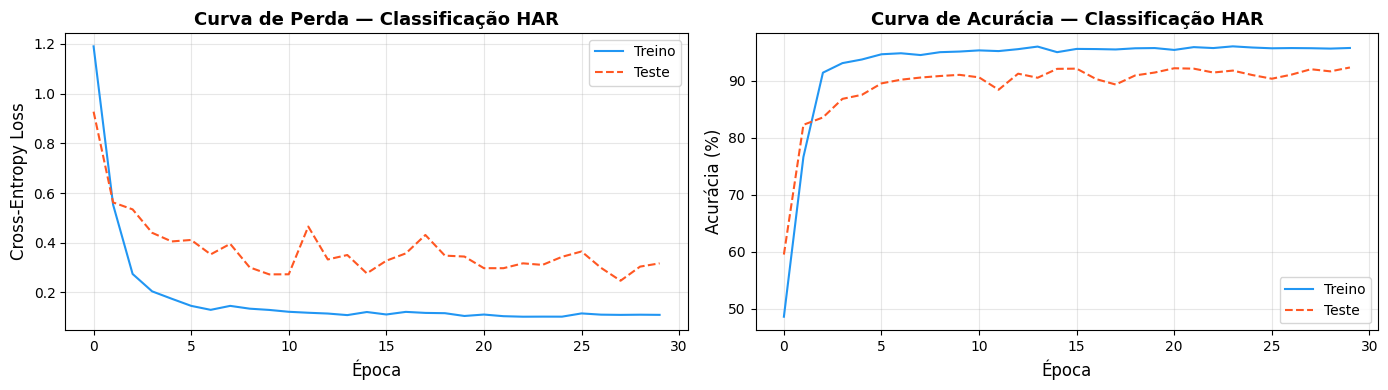


Acurácia final  Treino: 95.72%  |  Teste: 92.30%


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(hist_loss_tr_c, label="Treino", color="#2196F3", lw=1.5)
ax.plot(hist_loss_te_c, label="Teste",  color="#FF5722", lw=1.5, linestyle="--")
ax.set_xlabel("Época", fontsize=12)
ax.set_ylabel("Cross-Entropy Loss", fontsize=12)
ax.set_title("Curva de Perda  Classificação HAR", fontsize=13, fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot([a * 100 for a in hist_acc_tr_c], label="Treino", color="#2196F3", lw=1.5)
ax.plot([a * 100 for a in hist_acc_te_c], label="Teste",  color="#FF5722", lw=1.5, linestyle="--")
ax.set_xlabel("Época", fontsize=12)
ax.set_ylabel("Acurácia (%)", fontsize=12)
ax.set_title("Curva de Acurácia  Classificação HAR", fontsize=13, fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nAcurácia final  Treino: {hist_acc_tr_c[-1]*100:.2f}%  |  Teste: {hist_acc_te_c[-1]*100:.2f}%")

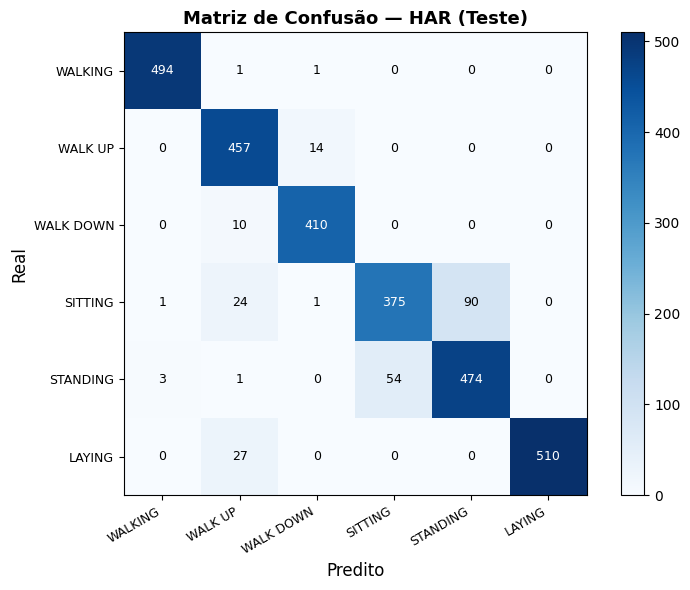


Acurácia por classe:
  WALKING     : 99.6%
  WALK UP     : 97.0%
  WALK DOWN   : 97.6%
  SITTING     : 76.4%
  STANDING    : 89.1%
  LAYING      : 95.0%


In [15]:
# Matriz de confusão
modelo_clf.eval()
with torch.no_grad():
    pred_te = modelo_clf(X_te_ct).argmax(1).cpu().numpy()

labels_curtos = ["WALKING", "WALK UP", "WALK DOWN", "SITTING", "STANDING", "LAYING"]

matriz = np.zeros((6, 6), dtype=int)
for real, pred in zip(y_te_c, pred_te):
    matriz[real, pred] += 1

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(matriz, cmap="Blues")
plt.colorbar(im, ax=ax)

ax.set_xticks(range(6)); ax.set_xticklabels(labels_curtos, rotation=30, ha="right", fontsize=9)
ax.set_yticks(range(6)); ax.set_yticklabels(labels_curtos, fontsize=9)
ax.set_xlabel("Predito",  fontsize=12)
ax.set_ylabel("Real",     fontsize=12)
ax.set_title("Matriz de Confusão  HAR (Teste)", fontsize=13, fontweight="bold")

thresh = matriz.max() / 2
for i in range(6):
    for j in range(6):
        ax.text(j, i, str(matriz[i, j]),
                ha="center", va="center", fontsize=9,
                color="white" if matriz[i, j] > thresh else "black")

plt.tight_layout()
plt.show()

acc_por_classe = matriz.diagonal() / matriz.sum(axis=1)
print("\nAcurácia por classe:")
for nome, acc in zip(labels_curtos, acc_por_classe):
    print(f"  {nome:<12}: {acc*100:.1f}%")


In [16]:
# ── 5.7 Salvar o modelo treinado ─────────────────────────────────────────────
# Mesma estratégia do Caso 1: checkpoint com pesos + metadados.

NOMES_ATIVIDADES = ["WALKING", "WALKING UPSTAIRS", "WALKING DOWNSTAIRS",
                    "SITTING", "STANDING", "LAYING"]

checkpoint_clf = {
    "model_state_dict": modelo_clf.state_dict(),
    "scaler_clf":       scaler_clf,          # normaliza os 9 canais inerciais
    "activity_labels":  NOMES_ATIVIDADES,    # rótulos das 6 classes
    "input_size":       9,                   # 9 canais de sensor
    "hidden_size":      128,
    "num_layers":       2,
    "num_classes":      6,
    "seq_len":          128,                 # 128 timesteps a 50 Hz = 2,56 s
}

torch.save(checkpoint_clf, "models/lstm_har.pth")
print("✓ Modelo HAR salvo em  models/lstm_har.pth")

✓ Modelo HAR salvo em  models/lstm_har.pth


---

## 6. Comparativo e Próximos Passos

### 6.1 FNN vs LSTM

| Aspecto | FNN (Aula 03) | LSTM (Aula 05) |
|---------|--------------|----------------|
| **Entrada** | Vetor fixo $(batch, features)$ | Sequência $(batch, seq\_len, features)$ |
| **Memória** | Nenhuma | $h_t$ e $c_t$ persistem entre passos |
| **Parâmetros** | Crescem com features | Crescem com `hidden_size` |
| **Dados temporais** | Trata passos como independentes | Captura dependências temporais |
| **Saída** | Vetor único | Vetor por passo ou apenas o último |

### 6.2 Many-to-One vs Many-to-Many

Nesta aula usamos a arquitetura **many-to-one**: a LSTM processa toda a sequência e gera uma única saída no último passo. Existem outras configurações:

| Configuração | Uso | Como implementar |
|-------------|-----|------------------|
| **Many-to-one** | Classificação, previsão de um passo | `output[:, -1, :]` |
| **Many-to-many** | Tradução, geração de sequências | `output` completo |
| **One-to-many** | Legenda de imagem, síntese | Entrada repetida a cada passo |

### 6.3 Próximos Passos

| Tópico | O que resolve |
|--------|---------------|
| **GRU** | Variante mais simples da LSTM  menos parâmetros, desempenho similar |
| **LSTM bidirecional** | Lê a sequência nos dois sentidos  captura contexto futuro |
| **Attention** | Pondera a importância de cada passo  base dos Transformers |
| **Transformer** | Substitui recorrência por atenção global  estado da arte em sequências |

In [17]:
print("=" * 60)
print("  RESUMO  Aula 05: LSTM com PyTorch")
print("=" * 60)
print()
print("  CASO 1  REGRESSÃO (Jena Climate)")
print(f"   Dataset     : {len(df):,} amostras horárias (2009-2016)")
print(f"   Arquitetura : LSTM(hidden=64, layers=2) → Linear(1)")
print(f"   Seq. length : {SEQ_LEN} horas de histórico")
print(f"   RMSE teste  : {rmse_te:.4f} °C")
print(f"   MAE  teste  : {mae_te:.4f} °C")
print(f"   R²   teste  : {r2_te:.4f}")
print()
print("  CASO 2  CLASSIFICAÇÃO (UCI HAR)")
print(f"   Dataset     : {len(y_tr_c):,} treino / {len(y_te_c):,} teste")
print(f"   Arquitetura : LSTM(hidden=128, layers=2) → Linear(6)")
print(f"   Seq. length : 128 timesteps  (9 canais inerciais)")
print(f"   Acurácia    : {hist_acc_te_c[-1]*100:.2f}%  (teste)")
print()
print("=" * 60)
print("  CONCEITOS CHAVE")
print("   • Gate de esquecimento : controla o que é descartado")
print("   • Gate de entrada      : decide o que memorizar")
print("   • Gate de saída        : filtra o que é exposto")
print("   • Estado de célula     : memória de longo prazo")
print("   • many-to-one          : sequência → valor/classe")
print("=" * 60)

  RESUMO  Aula 05: LSTM com PyTorch

  CASO 1  REGRESSÃO (Jena Climate)
   Dataset     : 70,089 amostras horárias (2009-2016)
   Arquitetura : LSTM(hidden=64, layers=2) → Linear(1)
   Seq. length : 24 horas de histórico
   RMSE teste  : 0.8084 °C
   MAE  teste  : 0.6021 °C
   R²   teste  : 0.9892

  CASO 2  CLASSIFICAÇÃO (UCI HAR)
   Dataset     : 7,352 treino / 2,947 teste
   Arquitetura : LSTM(hidden=128, layers=2) → Linear(6)
   Seq. length : 128 timesteps  (9 canais inerciais)
   Acurácia    : 92.30%  (teste)

  CONCEITOS CHAVE
   • Gate de esquecimento : controla o que é descartado
   • Gate de entrada      : decide o que memorizar
   • Gate de saída        : filtra o que é exposto
   • Estado de célula     : memória de longo prazo
   • many-to-one          : sequência → valor/classe
